# Preliminary Analysis of HARP2 data 

In [1]:
import earthaccess
import xarray as xr
import netCDF4
import os,re,copy,glob
import numpy as np
import matplotlib.pyplot as plt
import pickle 
import cartopy
import sys,os
import cartopy.crs as crs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from scipy.optimize import curve_fit
from matplotlib.lines import Line2D
import logging

import warnings
warnings.filterwarnings("ignore")

## Download Data 

In [2]:
auth = earthaccess.login(persist=True)

In [3]:
# results = earthaccess.search_datasets(instrument="oci")
# for item in results:
#     summary = item.summary()
#     print(summary["short-name"])

In [2]:
results = earthaccess.search_data(
    short_name="PACE_OCI_L2_CLOUD_MASK", 
    # short_name="PACE_OCI_L2_CLOUD",
    temporal=("2025-10-02T18:30:00", "2025-10-02T18:40:00"),
    count=1
)

In [3]:
# files = earthaccess.download(results, "/umbc/rs/pi_zzbatmos/common/Data/PACE/PACE_OCI_CLD_PROP")

### Load PACE Utility functions 

In [2]:
import PACE_Util_L2_V3_1

In [3]:
PACE_data_path_taki = '/umbc/rs/pi_zzbatmos/common/Data/PACE/'
PACE_OCI_L1B_data_path = os.path.join(PACE_data_path_taki,'PACE_OCI_L1B_SCI/')
PACE_OCI_L1C_data_path = os.path.join(PACE_data_path_taki,'PACE_OCI_L1C_SCI/')
PACE_HARP2_L1C_data_path = os.path.join(PACE_data_path_taki,'PACE_HARP2_L1C_SCI/hipp/')
PACE_OCI_L2_cloud_data_path = os.path.join(PACE_data_path_taki,'PACE_OCI_CLD_PROP/')

In [4]:
ts= '20251002T182635'          
H1C= PACE_Util_L2_V3_1.HARP2_L1(ts,data_level='L1C',data_path = PACE_HARP2_L1C_data_path,spr=True)
oci_l1b_granuel = PACE_Util_L2_V3_1.OCI_Level1B(ts,data_path=PACE_OCI_L1B_data_path)
oci_l1c_granuel = PACE_Util_L2_V3_1.OCI_Level1C(ts,data_path=PACE_OCI_L1C_data_path)
oci_l2cld_granuel = PACE_Util_L2_V3_1.OCI_L2_CLD_NRT(ts,data_path = PACE_OCI_L2_cloud_data_path)

#### Select a pixel using lat lon

In [5]:
lat_target = -10.6     
lon_target = -107.5    

lat = H1C.geolocation_data.latitude   # shape (396, 519)
lon = H1C.geolocation_data.longitude  # shape (396, 519)

# compute squared distance to target
dist = (lat - lat_target)**2 + (lon - lon_target)**2

# find nearest pixel
iy, ix = np.where(dist == np.min(dist))

print("Red dot pixel HARP2:", ix[0], iy[0])

Red dot pixel HARP2: 0 394


In [ ]:
x0_indices=[340], y0_indices=[260]
x0_indices=[310], y0_indices=[295]


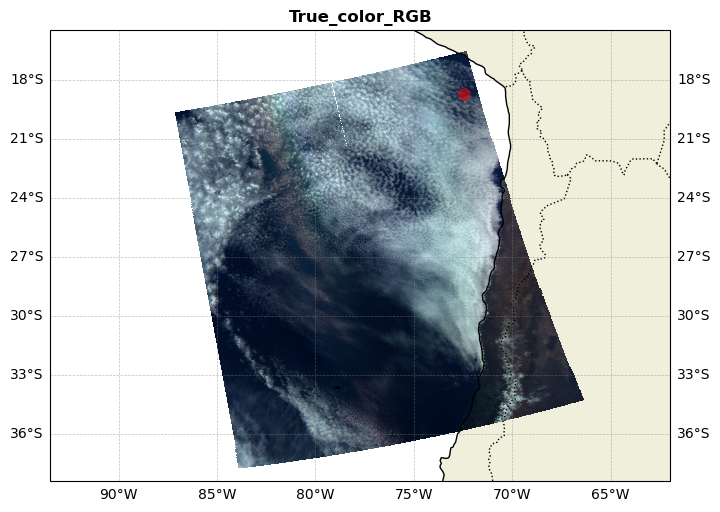

In [9]:
H1C.plot_true_color_RGB(figsize=[8, 6], x0_indices=[420], y0_indices=[350])

plt.savefig('HARP2_rgb_p3.png', dpi=500, bbox_inches="tight")

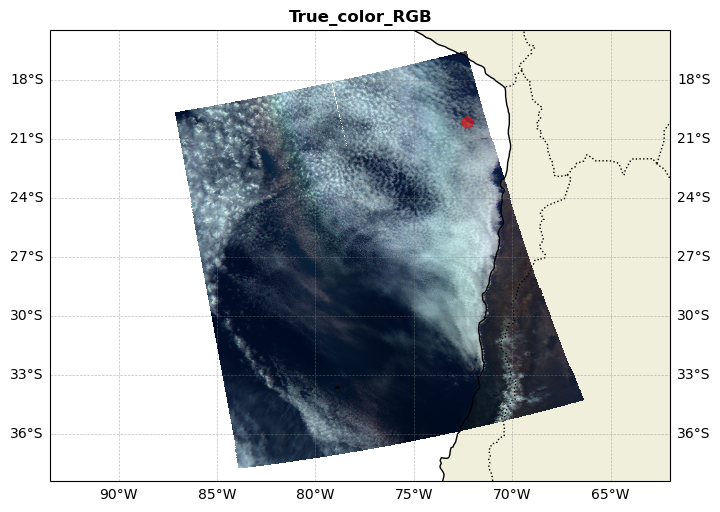

In [6]:
H1C.plot_true_color_RGB(figsize=[8, 6], x0_indices=[415], y0_indices=[320])

plt.savefig('HARP2_rgb_p4.png', dpi=500, bbox_inches="tight")

## Case Study

In [12]:
HARP2_L1C_clean= '20251002T182635'   

H1C_clean= PACE_Util_L2_V3_1.HARP2_L1(HARP2_L1C_clean, data_level='L1C',data_path = PACE_HARP2_L1C_data_path, spr=True)

In [45]:
x0_clean, y0_clean = 340, 260
# x0_clean, y0_clean = 310, 295

### Plot the RGB image of this case

1 10
[664.564]


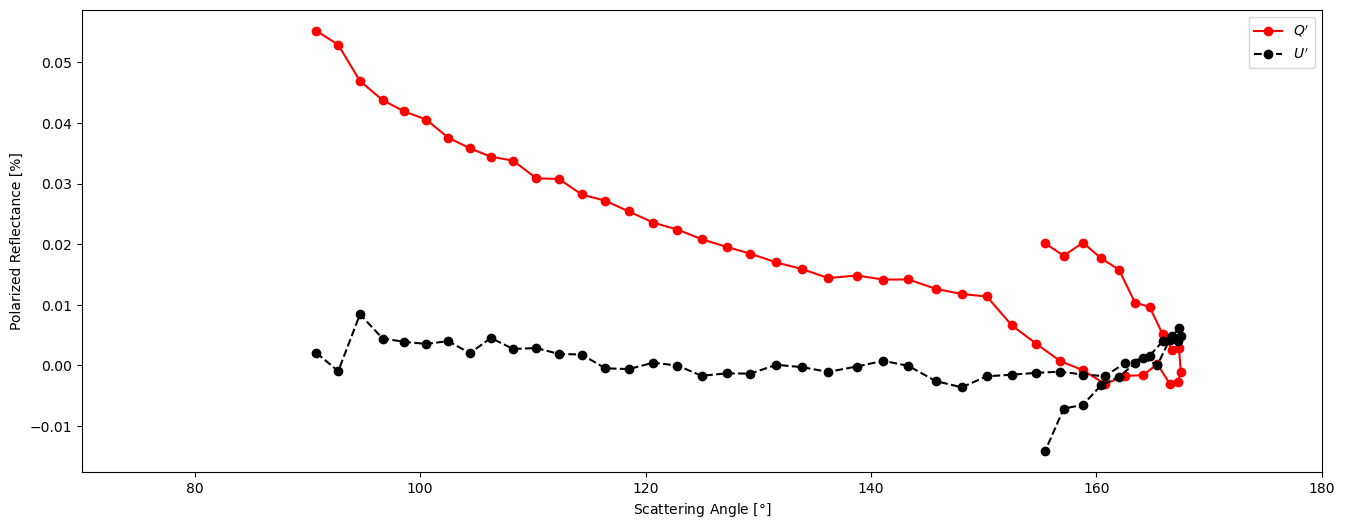

In [46]:
angle_range = [0, 10, 60, 80, 90]
color_index = ['b', 'g', 'r', 'tab:purple']

fig, ax = plt.subplots(figsize=(16, 6))  
ax.set_xlim([70, 180])

ax.set_xlabel(r'Scattering Angle [$\degree$]')
ax.set_ylabel('Polarized Reflectance [%]')     # r'Normalized $I_p$ [%]'

for ia in range(1, 2):
    print(ia, angle_range[ia])
    al = angle_range[ia]
    ar = angle_range[ia + 1]
    print(H1C_clean.sensors_views_bands.intensity_wavelength[al].values)

    label_text = ('{0:5.2f} nm'.format(H1C_clean.sensors_views_bands.intensity_wavelength[al].values[0]))

    # q_s_norm
    ax.plot(H1C_clean.geolocation_data.scattering_angle[y0_clean, x0_clean, al:ar],
            H1C_clean.q_s_norm[y0_clean, x0_clean, al:ar], label=r"$Q'$", c='r', marker='o')

    # u_s_norm
    ax.plot(H1C_clean.geolocation_data.scattering_angle[y0_clean, x0_clean, al:ar],
            H1C_clean.u_s_norm[y0_clean, x0_clean, al:ar], label=r"$U'$", c='k', marker='o', ls='dashed')

ax.legend(loc=0)
# plt.savefig("Normalized Q (Good).png", dpi=500, bbox_inches="tight")

### Load Polarized Phase Functions of water droplets for re and ve retrievals

In [33]:
class Water_Cloud_LUT():
    def __init__(self,LUT_nc_filename,LUT_par_list):
        ncf = netCDF4.Dataset(LUT_nc_filename,'r')
        self.LUT_par_dict={}
        for par in LUT_par_list:
            print('reading',par)
            self.LUT_par_dict[par]=np.array(ncf.variables[par])
            
LUT_ncfile='/umbc/rs/pi_zzbatmos/common/Data/cloud_bulk_scattering_prop.nc'     # new Lookup Table
LUT_par_list=['band','re','ve','angle','P11','P12']
WC_LUT=Water_Cloud_LUT(LUT_ncfile, LUT_par_list)

reading band
reading re
reading ve
reading angle
reading P11
reading P12


In [34]:
for k in WC_LUT.LUT_par_dict.keys():
    print(k, WC_LUT.LUT_par_dict[k].shape, WC_LUT.LUT_par_dict[k].min(), WC_LUT.LUT_par_dict[k].max())

band (3,) 0 2
re (145,) 4.0 40.0
ve (33,) 0.01 0.33
angle (720,) 0.0 179.75
P11 (3, 145, 33, 720) 0.0115498835 137480.67
P12 (3, 145, 33, 720) -1.3447073 2.6657605


In [35]:
print(WC_LUT.LUT_par_dict['band'])

[0 1 2]


In [36]:
print(WC_LUT.LUT_par_dict['re']) 

[ 4.    4.25  4.5   4.75  5.    5.25  5.5   5.75  6.    6.25  6.5   6.75
  7.    7.25  7.5   7.75  8.    8.25  8.5   8.75  9.    9.25  9.5   9.75
 10.   10.25 10.5  10.75 11.   11.25 11.5  11.75 12.   12.25 12.5  12.75
 13.   13.25 13.5  13.75 14.   14.25 14.5  14.75 15.   15.25 15.5  15.75
 16.   16.25 16.5  16.75 17.   17.25 17.5  17.75 18.   18.25 18.5  18.75
 19.   19.25 19.5  19.75 20.   20.25 20.5  20.75 21.   21.25 21.5  21.75
 22.   22.25 22.5  22.75 23.   23.25 23.5  23.75 24.   24.25 24.5  24.75
 25.   25.25 25.5  25.75 26.   26.25 26.5  26.75 27.   27.25 27.5  27.75
 28.   28.25 28.5  28.75 29.   29.25 29.5  29.75 30.   30.25 30.5  30.75
 31.   31.25 31.5  31.75 32.   32.25 32.5  32.75 33.   33.25 33.5  33.75
 34.   34.25 34.5  34.75 35.   35.25 35.5  35.75 36.   36.25 36.5  36.75
 37.   37.25 37.5  37.75 38.   38.25 38.5  38.75 39.   39.25 39.5  39.75
 40.  ]


In [37]:
print(WC_LUT.LUT_par_dict['ve'])

[0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13 0.14
 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27 0.28
 0.29 0.3  0.31 0.32 0.33]


In [38]:
iwl=0
ire=np.searchsorted(WC_LUT.LUT_par_dict['re'],[4,20,40])
ive=np.searchsorted(WC_LUT.LUT_par_dict['ve'],[0.01,0.15,0.33])
print(ire)
print(ive)

[  0  64 144]
[ 1 14 32]


Text(122, 0.52, 'b)')

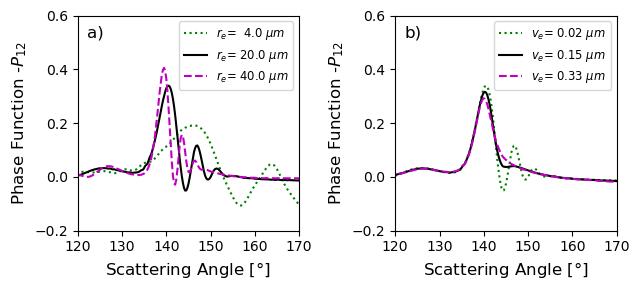

In [39]:
fig,ax=plt.subplots(1,2,figsize=[6.5,3],tight_layout=True)
ls=['dotted','solid','dashed']
color=['g','k','m']
n=0

# varying re, fixed ve
for i in ire:
    ax[0].plot(WC_LUT.LUT_par_dict['angle'], -WC_LUT.LUT_par_dict['P12'][iwl,i,ive[0],:],
               ls=ls[n],c=color[n],label=r'$r_e$={0:5.1f} $\mu m$'.format(WC_LUT.LUT_par_dict['re'][i]))
    n+=1

# varying ve, fixed re
n=0
for j in ive:
    ax[1].plot(WC_LUT.LUT_par_dict['angle'], -WC_LUT.LUT_par_dict['P12'][iwl,ire[1],j,:],
               ls=ls[n],c=color[n],label=r'$v_e$={0:5.2f} $\mu m$'.format(WC_LUT.LUT_par_dict['ve'][j]))  
    n+=1

for axis in ax:
    axis.legend(loc=0,ncol=1,fontsize='small')
    axis.set_xlim([120,170])
    axis.set_ylim([-0.2,0.6])
    axis.set_xlabel(r'Scattering Angle [$\degree$]',fontsize='large')
    axis.set_ylabel(r'Phase Function -$P_{12}$',fontsize='large')
ax[0].text(122,0.52,'a)',fontsize='large')
ax[1].text(122,0.52,'b)',fontsize='large')
# fig.savefig('HARP_CER_CER_retrieval_illustration.png', dpi=500, bbox_inches="tight")

In [40]:
# This algorithm fits observed polarized reflectance to precomputed polarized phase functions LUT
def Rp_mod(x,a,b,c):
    sca=x[0,:]
    P12=x[1,:]
    #y=a*P12+b*np.cos(np.deg2rad(sca))**2+c
    y=a*P12+b*sca+c
    return y

def Qual_index(P12,Robs,Rfit):
    P12_var = np.mean(P12**2)-np.mean(P12)**2
    RMS = np.mean((Robs-Rfit)**2)
    return P12_var/ RMS

re best fit 5.5
ve best fit 0.03


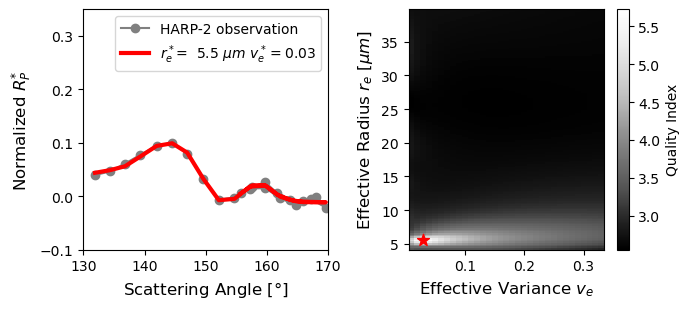

In [41]:
al, ar = 10,60
bd_index = 0
sca_range = [130,170]
sca_range_index = (H1C_clean.geolocation_data.scattering_angle[y0_clean,x0_clean,al:ar] > sca_range[0]) &\
                  (H1C_clean.geolocation_data.scattering_angle[y0_clean,x0_clean,al:ar] < sca_range[1])  

Sca_obs = H1C_clean.geolocation_data.scattering_angle[y0_clean,x0_clean,al:ar][sca_range_index]
Rp_obs = H1C_clean.q_s_norm[y0_clean,x0_clean,al:ar][sca_range_index]
Sca_lut = WC_LUT.LUT_par_dict['angle']

Nre, Nve = WC_LUT.LUT_par_dict['re'].size, WC_LUT.LUT_par_dict['ve'].size

fig, ax = plt.subplots(1,2,figsize=(7,3.2),tight_layout=True)
ax[0].set_xlim(sca_range)
ax[0].set_ylim([-0.1,0.35])
ax[0].plot(Sca_obs, Rp_obs, marker='o', c='gray', label='HARP-2 observation')

fitting_qual=np.zeros([Nre,Nve])
fitting_par=np.zeros([Nre,Nve,3])
for re_index in range(0,Nre):
    for ve_index in range(0,Nve):
        p12_lut   = np.interp(Sca_obs, Sca_lut, WC_LUT.LUT_par_dict['P12'][bd_index,re_index,ve_index,:])
        predictor = np.stack((Sca_obs, p12_lut))
        popt, pcov = curve_fit(Rp_mod, predictor, Rp_obs, p0=[-1,-1,0])
        Rp_fit=Rp_mod(predictor,*popt)
        
        fitting_qual[re_index,ve_index]= Qual_index(p12_lut, Rp_obs, Rp_fit)
        fitting_par[re_index,ve_index,:]= popt

Qual= fitting_qual
best_fit_re_index, best_fit_ve_index= np.unravel_index(fitting_qual.argmax(),fitting_qual.shape)

re_best_fit=WC_LUT.LUT_par_dict['re'][best_fit_re_index]
ve_best_fit=WC_LUT.LUT_par_dict['ve'][best_fit_ve_index] 
# print retrievals
print('re best fit',re_best_fit)
print('ve best fit',ve_best_fit)

# Best fit parameters
Qual_best_fit = fitting_qual[best_fit_re_index, best_fit_ve_index]
par_best_fit = fitting_par[best_fit_re_index, best_fit_ve_index,:]
a,b,c = par_best_fit

p12_best_fit= np.interp(Sca_obs,Sca_lut,WC_LUT.LUT_par_dict['P12'][bd_index,best_fit_re_index,best_fit_ve_index,:])
predictor_best_fit = np.stack((Sca_obs, p12_best_fit))

ax[0].plot(Sca_obs, Rp_mod(predictor_best_fit,a,b,c), c='r',
           label=r'$r_e^*$={0:5.1f} $\mu m$ $v_e^*={1:5.2}$'.format(re_best_fit,ve_best_fit), ls='solid', lw=3.0)
ax[0].set_xlabel(r'Scattering Angle [$\degree$]',fontsize='large')
ax[0].set_ylabel(r'Normalized $R^{*}_P$',fontsize='large')
ax[0].legend(loc='upper right')

# Quality Index plot
ve, re= WC_LUT.LUT_par_dict['ve'], WC_LUT.LUT_par_dict['re']
re_index= (4<re) & (re<40)

cf=ax[1].pcolormesh(ve, re[re_index], np.log(Qual[re_index,:]), cmap='Greys_r')
ax[1].scatter(ve_best_fit, re_best_fit, c='r', marker='*', s=80)
cbar=plt.colorbar(cf,ax=ax[1])
cbar.set_label('Quality Index')
ax[1].set_xlabel(r'Effective Variance $v_e$',fontsize='large')
ax[1].set_ylabel(r'Effective Radius $r_e$ $[\mu m]$',fontsize='large')

plt.tight_layout()
# plt.savefig('HARP2_cloud_microphysics_retrieval.png', dpi=500, bbox_inches="tight")
plt.show()

### Plotting the whole phase function (to visualize overfitting)

re best fit: 5.5
ve best fit: 0.03


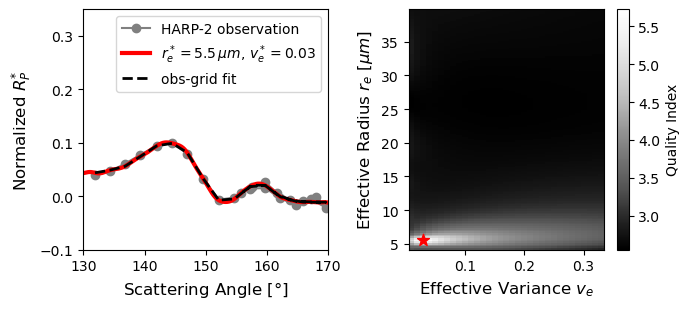

In [42]:
al, ar = 10, 60
bd_index = 0
sca_range = [130, 170]
sca_range_index = (H1C_clean.geolocation_data.scattering_angle[y0_clean, x0_clean, al:ar] > sca_range[0]) &\
                  (H1C_clean.geolocation_data.scattering_angle[y0_clean, x0_clean, al:ar] < sca_range[1])

Sca_obs = H1C_clean.geolocation_data.scattering_angle[y0_clean, x0_clean, al:ar][sca_range_index]
Rp_obs = H1C_clean.q_s_norm[y0_clean, x0_clean, al:ar][sca_range_index]
Sca_lut = WC_LUT.LUT_par_dict['angle']

Nre, Nve = WC_LUT.LUT_par_dict['re'].size, WC_LUT.LUT_par_dict['ve'].size

fig, ax = plt.subplots(1, 2, figsize=(7,3.2), tight_layout=True)
ax[0].set_xlim(sca_range)
ax[0].set_ylim([-0.1, 0.35])
ax[0].plot(Sca_obs, Rp_obs, marker='o', c='gray', label='HARP-2 observation')

# Fitting loop
fitting_qual = np.zeros([Nre, Nve])
fitting_par = np.zeros([Nre, Nve, 3])

for re_index in range(Nre):
    for ve_index in range(Nve):
        # interpolate phase function from LUT to observation angular grid
        p12_lut = np.interp(Sca_obs, Sca_lut, WC_LUT.LUT_par_dict['P12'][bd_index, re_index, ve_index, :])
        predictor = np.stack((Sca_obs, p12_lut))
        try:
            popt, pcov = curve_fit(Rp_mod, predictor, Rp_obs, p0=[-1,-1,0])
        except Exception:
            popt = np.array([np.nan,np.nan,np.nan])

        Rp_fit = Rp_mod(predictor, *popt)
        fitting_qual[re_index, ve_index] = Qual_index(p12_lut, Rp_obs, Rp_fit)
        fitting_par[re_index, ve_index, :] = popt

Qual = fitting_qual
best_fit_re_index, best_fit_ve_index = np.unravel_index(np.nanargmax(fitting_qual), fitting_qual.shape)

re_best_fit = WC_LUT.LUT_par_dict['re'][best_fit_re_index]
ve_best_fit = WC_LUT.LUT_par_dict['ve'][best_fit_ve_index]
print('re best fit:', re_best_fit)
print('ve best fit:', ve_best_fit)

# Best fit parameters
Qual_best_fit = fitting_qual[best_fit_re_index, best_fit_ve_index]
par_best_fit = fitting_par[best_fit_re_index, best_fit_ve_index, :]
a, b, c = par_best_fit

# Optional: Observation grid fit (coarse res)
p12_best_fit=np.interp(Sca_obs,Sca_lut,WC_LUT.LUT_par_dict['P12'][bd_index,best_fit_re_index,best_fit_ve_index,:])
predictor_best_fit = np.stack((Sca_obs, p12_best_fit))
Rp_obsgrid_fit = Rp_mod(predictor_best_fit, a, b, c)

# fit on HIGH-RES LUT grid (to preserve bow structure)
Sca_highres = WC_LUT.LUT_par_dict['angle']
p12_highres = WC_LUT.LUT_par_dict['P12'][bd_index, best_fit_re_index, best_fit_ve_index, :]
predictor_highres = np.stack((Sca_highres, p12_highres))
Rp_highres_fit = Rp_mod(predictor_highres, a, b, c)

ax[0].plot(Sca_highres, Rp_highres_fit, c='r', lw=3.0, ls='solid', 
           label=rf'$r_e^*={re_best_fit:5.1f}\,\mu m$, $v_e^*={ve_best_fit:5.2f}$')
ax[0].plot(Sca_obs, Rp_obsgrid_fit, c='k', lw=2.0, ls='dashed', label='obs-grid fit')
ax[0].set_xlabel(r'Scattering Angle [$\degree$]', fontsize='large')
ax[0].set_ylabel(r'Normalized $R^{*}_P$', fontsize='large')
ax[0].legend(loc='upper right')

# Quality Index plot
ve = WC_LUT.LUT_par_dict['ve']
re = WC_LUT.LUT_par_dict['re']
re_index = (re > 4) & (re < 40)

cf=ax[1].pcolormesh(ve, re[re_index], np.log(Qual[re_index,:]), cmap='Greys_r')
ax[1].scatter(ve_best_fit, re_best_fit, c='r', marker='*', s=80)
cbar=plt.colorbar(cf, ax=ax[1])
cbar.set_label('Quality Index')
ax[1].set_xlabel(r'Effective Variance $v_e$', fontsize='large')
ax[1].set_ylabel(r'Effective Radius $r_e$ $[\mu m]$',fontsize='large')

plt.tight_layout()
# plt.savefig('HARP2_cloud_microphysics_retrieval2.png', dpi=500, bbox_inches="tight")
plt.show()

### Two time retrieval (i.e Interpolating to High Res (LUT) and using this as the New Observation)

Sca_obs min, max: 131.88999938964844 169.61000061035156
Sca_newobs min, max: 132.0 169.5

re retrieved: 5.5
ve retrieved: 0.06


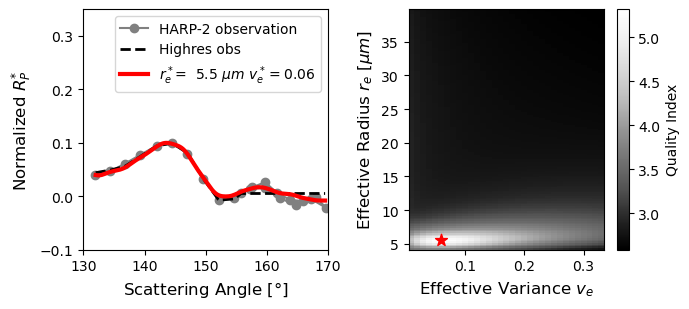

In [44]:
fig, ax = plt.subplots(1, 2, figsize=(7,3.2), tight_layout=True)       # (8, 3.5)

ax[0].set_xlim([130,170])
ax[0].set_ylim([-0.1, 0.35])
ax[0].plot(Sca_obs, Rp_obs, marker='o', c='gray', label='HARP-2 observation')
print('Sca_obs min, max:', float(Sca_obs.min()), float(Sca_obs.max()))

# interpolate to High Res
Rp_lut= np.interp(Sca_lut, Sca_obs, Rp_obsgrid_fit)    

# New observation
sca_range_index = (Sca_lut>=float(Sca_obs.min())) & (Sca_lut<=float(Sca_obs.max())) 
Sca_newobs = Sca_lut[sca_range_index]
Rp_newobs  = Rp_lut[sca_range_index] 

ax[0].plot(Sca_newobs, Rp_newobs, c='k', lw=2.0, ls='dashed', label='Highres obs')
print('Sca_newobs min, max:', Sca_newobs.min(), Sca_newobs.max())

fitting_qual_new = np.zeros([Nre, Nve])
fitting_par_new  = np.zeros([Nre, Nve, 3])
for re_index in range(Nre):      # Loop over all (re, ve) to find best match
    for ve_index in range(Nve):      
        p12_new = np.interp(Sca_newobs, Sca_lut, WC_LUT.LUT_par_dict['P12'][bd_index, re_index, ve_index, :])
        predictor_new = np.stack((Sca_newobs, p12_new))
        try:
            popt_new, _ = curve_fit(Rp_mod, predictor_new, Rp_newobs, p0=[-1, -1, 0])
        except Exception:
            popt_new = np.array([np.nan, np.nan, np.nan])

        Rp_fit_new = Rp_mod(predictor_new, *popt_new)
        fitting_qual_new[re_index, ve_index] = Qual_index(p12_new, Rp_newobs, Rp_fit_new)
        fitting_par_new[re_index, ve_index, :] = popt_new
        
Qual = fitting_qual_new
best_re_new, best_ve_new = np.unravel_index(np.nanargmax(fitting_qual_new), fitting_qual_new.shape)

re_best_fit_new = WC_LUT.LUT_par_dict['re'][best_re_new]
ve_best_fit_new = WC_LUT.LUT_par_dict['ve'][best_ve_new]
print("")
print("re retrieved:", re_best_fit_new)
print("ve retrieved:", ve_best_fit_new)

Qual_best_fit_new = fitting_qual_new[best_re_new, best_ve_new]
par_best_fit_new = fitting_par_new[best_re_new, best_ve_new, :]
a, b, c = par_best_fit_new

p12_best_fit_new= np.interp(Sca_newobs,Sca_lut,WC_LUT.LUT_par_dict['P12'][bd_index,best_re_new,best_ve_new,:])
predictor_best_fit_new = np.stack((Sca_newobs, p12_best_fit_new))

ax[0].plot(Sca_newobs, Rp_mod(predictor_best_fit_new,a,b,c), c='r',
           label=r'$r_e^*$={0:5.1f} $\mu m$ $v_e^*={1:5.2}$'.format(re_best_fit_new,ve_best_fit_new), ls='solid', lw=3.0)
ax[0].set_xlabel(r'Scattering Angle [$\degree$]', fontsize='large')
ax[0].set_ylabel(r'Normalized $R^{*}_P$', fontsize='large')
ax[0].legend(loc='upper right')

# Quality Index plot
ve = WC_LUT.LUT_par_dict['ve']
re = WC_LUT.LUT_par_dict['re']
re_index = (re > 4) & (re < 40)

cf=ax[1].pcolormesh(ve, re[re_index], np.log(Qual[re_index,:]), cmap='Greys_r')
ax[1].scatter(ve_best_fit_new, re_best_fit_new, c='r', marker='*', s=80)
cbar=plt.colorbar(cf, ax=ax[1])
cbar.set_label('Quality Index')
ax[1].set_xlabel(r'Effective Variance $v_e$', fontsize='large')
ax[1].set_ylabel(r'Effective Radius $r_e$ $[\mu m]$',fontsize='large')

plt.tight_layout()
plt.savefig('HARP2_cloud_microphysics_retrieval_2x_p2.png', dpi=500, bbox_inches="tight")
plt.show()